# Ensemble training and held-out evaluation

This tutorial is for users who know the basics of neural-network potential training and want to use a committee as a reproducible uncertainty indicator. It trains a deliberately small, energy-only committee for a TiO$_2$ model, reloads it from disk, measures prediction error on structures that were not used for training or validation, and compares error with committee spread.

The notebook demonstrates how to create shared deterministic data partitions, train independently seeded committee members, inspect saved metadata, evaluate ensemble predictions, and rank structures by model disagreement. The modest networks and five-member committee keep the workflow practical on a CPU; they do **not** produce a deployable potential.

**Requirements:** PyTorch plus matching `torch-scatter` and `torch-cluster` wheels. The executable workflow does not require aenet executables or `libaenet`.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Subset

if Path("xsf-TiO2").exists():
    notebook_dir = Path(".")
else:
    notebook_dir = Path("notebooks")

data_dir = notebook_dir / "xsf-TiO2"
outdir = notebook_dir / "example-09-outputs"
committee_dir = outdir / "committee_run"
outdir.mkdir(parents=True, exist_ok=True)

structure_paths = sorted(data_dir.glob("*.xsf"))
assert len(structure_paths) == 100, "Expected the maintained 100-structure TiO2 subset"
print(f"PyTorch {torch.__version__}")
print(f"Found {len(structure_paths)} structures in {data_dir}")

PyTorch 2.9.0
Found 100 structures in xsf-TiO2


## 1. Configure and cache the descriptor

The structures are a maintained random subset of the TiO$_2$ data from N. Artrith and A. Urban, *Computational Materials Science* **114** (2016) 135–150. We use the same compact Chebyshev descriptor and atomic reference energies as the general PyTorch training example. Caching features once makes repeated committee training inexpensive.

In [2]:
from aenet.torch_featurize import ChebyshevDescriptor
from aenet.torch_training.dataset import CachedStructureDataset

descriptor = ChebyshevDescriptor(
    species=["Ti", "O"],
    rad_order=10,
    rad_cutoff=6.0,
    ang_order=3,
    ang_cutoff=3.5,
    min_cutoff=0.5,
    device="cpu",
    dtype=torch.float64,
)

atomic_energies = {"O": -432.503149303, "Ti": -1604.604515075}
dataset = CachedStructureDataset(
    structures=structure_paths,
    descriptor=descriptor,
    atomic_energies=atomic_energies,
    show_progress=False,
)
print(f"Cached {len(dataset)} structures for energy-only training")

Cached 100 structures for energy-only training


## 2. Make deterministic train, validation, and test partitions

A committee should vary model initialization and training order, not the evidence shown to each member. We therefore randomize indices once with an explicit split seed and reuse the resulting 70/15/15 partitions for every member. The validation partition supplies training diagnostics; the held-out test partition is reserved for the final evaluation.

In [3]:
split_seed = 2026
indices = np.random.default_rng(split_seed).permutation(len(dataset))
train_indices = indices[:70].tolist()
validation_indices = indices[70:85].tolist()
test_indices = indices[85:].tolist()

train_dataset = Subset(dataset, train_indices)
validation_dataset = Subset(dataset, validation_indices)
test_dataset = Subset(dataset, test_indices)

partition_sets = [set(train_indices), set(validation_indices), set(test_indices)]
assert set.union(*partition_sets) == set(range(len(dataset)))
assert sum(len(part) for part in partition_sets) == len(set.union(*partition_sets))
print(
    f"split_seed={split_seed}: train={len(train_dataset)}, "
    f"validation={len(validation_dataset)}, test={len(test_dataset)}"
)

split_seed=2026: train=70, validation=15, test=15


## 3. Train independently seeded members

All members share the architecture, descriptor, optimizer settings, and the explicit train/validation datasets. Their run seeds differ, which changes initialization and stochastic training order. Here we use sequential CPU execution (`max_parallel=1`) for the sake of simplicity. Five hundred training iterations provide a useful tutorial result while retaining a reasonably short runtime, but this example does not establish scientific convergence.

In [4]:
from aenet.torch_training import (
    Adam,
    TorchCommitteeConfig,
    TorchCommitteePotential,
    TorchTrainingConfig,
)

architecture = {
    "Ti": [(8, "tanh"), (8, "tanh")],
    "O": [(8, "tanh"), (8, "tanh")],
}
training_config = TorchTrainingConfig(
    atomic_energies=atomic_energies,
    testpercent=0,
    iterations=500,
    method=Adam(mu=0.001, batchsize=16),
    memory_mode="cpu",
    device="cpu",
    show_progress=False,
    checkpoint_dir=None,
    checkpoint_interval=0,
    max_checkpoints=None,
    save_best=False,
    use_scheduler=False,
)
committee_config = TorchCommitteeConfig(
    num_members=5,
    member_seeds=[3101, 3102, 3103, 3104, 3105],
    max_parallel=1,
    output_dir=committee_dir,
)
committee = TorchCommitteePotential(architecture, descriptor=descriptor)
training_result = committee.train(
    train_dataset=train_dataset,
    test_dataset=validation_dataset,
    config=training_config,
    committee_config=committee_config,
)
assert not training_result.failed_members
training_result.to_dataframe()[
    ["member", "seed", "status", "final_RMSE_train", "final_RMSE_test"]
]

,member,seed,status,final_RMSE_train,final_RMSE_test
0,0,3101,completed,0.015102,0.251258
1,1,3102,completed,0.015844,0.195688
2,2,3103,completed,0.014951,0.179927
3,3,3104,completed,0.011473,0.143697
4,4,3105,completed,0.009599,0.173443


Note: The validation column retains the API's historical `test` name, but here it is strictly the *validation* partition. The genuinely held-out test data has not yet been evaluated. Variation among the rows is expected because the members have distinct seeds.

## 4. Inspect metadata and reload from disk

Each run stores `committee_metadata.json` plus one directory per member containing its model, history, and summary. Reloading from this directory verifies that later inference does not depend on the in-memory training object.

In [5]:
metadata = json.loads(training_result.metadata_path.read_text(encoding="utf-8"))
metadata_summary = {
    "schema_version": metadata["schema_version"],
    "execution_mode": metadata["execution_mode"],
    "member_seeds": [member["seed"] for member in metadata["members"]],
    "train_dataset": metadata["resolved_train_dataset"],
    "validation_dataset": metadata["resolved_test_dataset"],
}
print("Metadata:")
print(json.dumps(metadata_summary, indent=2))

reloaded_committee = TorchCommitteePotential.from_directory(committee_dir, device="cpu")
assert len(reloaded_committee.member_model_paths()) == committee_config.num_members

Metadata:
{
  "schema_version": "1.0",
  "execution_mode": "sequential",
  "member_seeds": [
    3101,
    3102,
    3103,
    3104,
    3105
  ],
  "train_dataset": "Subset[CachedStructureDataset]",
  "validation_dataset": "Subset[CachedStructureDataset]"
}


## 5. Predict the held-out structures

The ensemble mean is the reported prediction and the population standard deviation across member energies is the raw committee spread. We divide energies, errors, and spreads by atom count so structures of different sizes are comparable.

In [6]:
predictions = reloaded_committee.predict_dataset(test_dataset, eval_forces=False)
prediction_table = predictions.to_dataframe()
source_indices = prediction_table["source_index"].astype(int).to_numpy()
reference_energy = np.array([dataset.get_structure(i).energy for i in source_indices])
n_atoms = np.array([dataset.get_structure(i).n_atoms for i in source_indices])

evaluation = pd.DataFrame(
    {
        "source_index": source_indices,
        "identifier": prediction_table["identifier"],
        "n_atoms": n_atoms,
        "reference_eV_per_atom": reference_energy / n_atoms,
        "prediction_eV_per_atom": predictions.energy_mean / n_atoms,
        "spread_eV_per_atom": predictions.energy_std / n_atoms,
    }
)
evaluation["error_eV_per_atom"] = (
    evaluation["prediction_eV_per_atom"] - evaluation["reference_eV_per_atom"]
)
evaluation["abs_error_eV_per_atom"] = evaluation["error_eV_per_atom"].abs()
evaluation.head()

,source_index,identifier,n_atoms,reference_eV_per_atom,prediction_eV_per_atom,spread_eV_per_atom,error_eV_per_atom,abs_error_eV_per_atom
0,49,xsf-TiO2/structure-050.xsf,23,-848.592403,-848.590625,0.011463,0.001779,0.001779
1,13,xsf-TiO2/structure-014.xsf,6,-830.973971,-830.960065,0.041802,0.013906,0.013906
2,34,xsf-TiO2/structure-035.xsf,6,-831.638246,-831.619654,0.024045,0.018592,0.018592
3,79,xsf-TiO2/structure-080.xsf,23,-848.480563,-848.421411,0.032079,0.059152,0.059152
4,78,xsf-TiO2/structure-079.xsf,22,-866.900546,-866.888284,0.034420,0.012262,0.012262


## 6. Measure held-out accuracy

Held-out mean absolute error (MAE) and root-mean-square error (RMSE) summarize ensemble accuracy. These demonstration values characterize only this small random partition and the specific tutorial training configuration.

In [7]:
errors = evaluation["error_eV_per_atom"].to_numpy()
ensemble_mae = np.mean(np.abs(errors))
ensemble_rmse = np.sqrt(np.mean(errors**2))
member_mae = []
for member_index, member_output in enumerate(predictions.member_outputs):
    member_error = np.asarray(member_output.total_energy) / n_atoms - reference_energy / n_atoms
    member_mae.append(
        {"predictor": f"member {member_index}", "MAE (eV/atom)": np.mean(np.abs(member_error))}
    )
member_mae.append({"predictor": "ensemble mean", "MAE (eV/atom)": ensemble_mae})
print(f"Held-out ensemble MAE:  {ensemble_mae:.4f} eV/atom")
print(f"Held-out ensemble RMSE: {ensemble_rmse:.4f} eV/atom")
pd.DataFrame(member_mae)

Held-out ensemble MAE:  0.1001 eV/atom
Held-out ensemble RMSE: 0.2287 eV/atom


,predictor,MAE (eV/atom)
0,member 0,0.111762
1,member 1,0.139162
2,member 2,0.100361
3,member 3,0.057425
4,member 4,0.140840
5,ensemble mean,0.100149


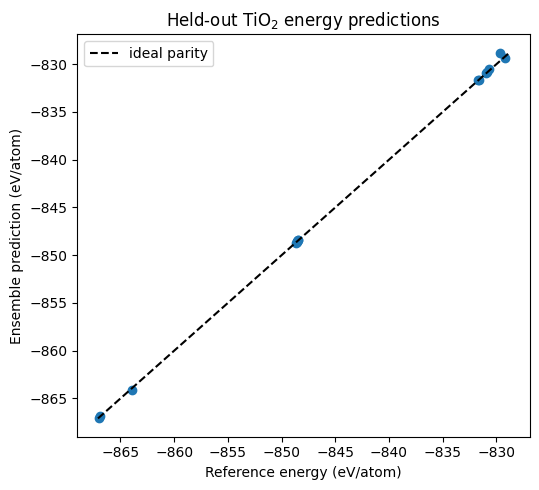

In [8]:
fig, ax = plt.subplots(figsize=(5.5, 5))
ax.scatter(
    evaluation["reference_eV_per_atom"],
    evaluation["prediction_eV_per_atom"],
    color="tab:blue",
)
limits = [
    min(evaluation["reference_eV_per_atom"].min(), evaluation["prediction_eV_per_atom"].min()),
    max(evaluation["reference_eV_per_atom"].max(), evaluation["prediction_eV_per_atom"].max()),
]
ax.plot(limits, limits, "k--", label="ideal parity")
ax.set(xlabel="Reference energy (eV/atom)", ylabel="Ensemble prediction (eV/atom)")
ax.legend()
ax.set_title("Held-out TiO$_2$ energy predictions")
fig.tight_layout()
plt.show()

Points close to the parity line have small prediction error. Systematic offsets or trends would indicate shortcomings in the model, training duration, reference energies, or representativeness of the training data.

## 7. Compare error with committee spread

Member disagreement can help prioritize structures for labeling or review. A useful committee should often disagree more on difficult or unfamiliar structures, but raw spread is only a heuristic. Members can agree and still be wrong, and the numerical spread is not automatically a calibrated error bar.

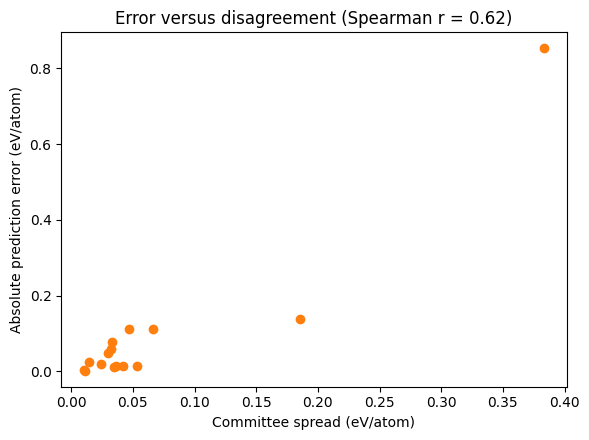

In [9]:
rank_correlation = evaluation["abs_error_eV_per_atom"].corr(
    evaluation["spread_eV_per_atom"], method="spearman"
)
fig, ax = plt.subplots(figsize=(6, 4.5))
ax.scatter(
    evaluation["spread_eV_per_atom"],
    evaluation["abs_error_eV_per_atom"],
    color="tab:orange",
)
ax.set(
    xlabel="Committee spread (eV/atom)",
    ylabel="Absolute prediction error (eV/atom)",
    title=f"Error versus disagreement (Spearman r = {rank_correlation:.2f})",
)
fig.tight_layout()
plt.show()

In [10]:
ranking = evaluation.sort_values("spread_eV_per_atom", ascending=False)
ranking[
    [
        "identifier",
        "spread_eV_per_atom",
        "abs_error_eV_per_atom",
    ]
].head(5)

,identifier,spread_eV_per_atom,abs_error_eV_per_atom
12,xsf-TiO2/structure-064.xsf,0.383066,0.852499
8,xsf-TiO2/structure-041.xsf,0.185852,0.139382
10,xsf-TiO2/structure-027.xsf,0.066011,0.111540
5,xsf-TiO2/structure-024.xsf,0.053480,0.013776
9,xsf-TiO2/structure-072.xsf,0.046883,0.112874


This ranking demonstrates a common active-learning operation: inspect the structures with the largest committee spread first. The adjacent error column is available here only because this tutorial has reference labels; it should not be treated as known for an unlabeled candidate pool. With five members and only 15 test structures, the correlation is descriptive rather than evidence of uncertainty calibration.

## Optional extensions

Forces can be included by using force-labeled structures and setting a nonzero `force_weight` in `TorchTrainingConfig`. Force training is substantially more expensive and is omitted from this tutorial; an energy-only committee cannot assess force accuracy or force uncertainty.

A reloaded committee can also be exported with `reloaded_committee.to_aenet_ascii(outdir / "committee_ascii", structures=dataset.structures)`. Export does not require executing compiled aenet components, but using the resulting files with `AenetEnsembleInterface` or `AenetEnsembleCalculator` requires a configured `libaenet` backend.

## Summary

We created deterministic train, validation, and held-out test partitions; varied only the member training seeds; persisted and reloaded the complete committee; evaluated ensemble accuracy; and ranked test structures by disagreement. A realistic potential would use more representative data, larger models and committees, convergence studies, force training where appropriate, and a separate calibration analysis before interpreting spread quantitatively.